In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import boto3

#### Functions

In [2]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [3]:
# str uri
str_uri = 's3://20250121-gen-13-model-monitoring/07_compare_debtor/df.gzip'

# output
str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# dict sort
dict_sort = {
    'A1': 1,
    'A': 2,
    'B': 3,
    'C': 4,
    'D': 5,
    'Decline': 6,
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

#### Load in data

In [4]:
df = pd.read_parquet(str_uri)
list_cols_ = [col for col in list(df.columns) if 'loan' in col]
list_cols_

['shorttermloanrequest__ln',
 'shorttermloanrequest12month__ln',
 'shorttermloanrequest24month__ln',
 'str_loan_type__tu_pmthx',
 'ENG-loan_to_value']

# LTV, g232s and rp01s

In [5]:
# pull data
df = pd.read_parquet(str_uri)

# subset BKs
# df = df[df['intopenbktype__app'].isna()]

# impute
df['g232s__tu'] = df['g232s__tu'].fillna(999)
df['rp01s__tu'] = df['rp01s__tu'].fillna(999)

# group by
df = df.groupby('accountid').agg({
#     'pd_gen13': 'mean', 
#     'lgd_gen13': 'mean',
    'pd_gen12': 'mean', 
    'lgd_gen12': 'mean',    
    'g232s__tu': 'max',
    'rp01s__tu': 'max',
    'ENG-loan_to_value': 'mean',
#     'ENG-wtd_avg': 'mean',
}).reset_index()

# calculate ecnl_gen12
df['ecnl_gen12'] = df['pd_gen12'] * df['lgd_gen12'] * flt_factor_24_to_72

# calculate updated ecnl
df['ecnl_g232s'] = df.apply(lambda row: 1.0 if row['g232s__tu'] > 31 else row['ecnl_gen12'], axis=1)
df['ecnl_rp01s'] = df.apply(lambda row: 1.0 if row['rp01s__tu'] > 1 else row['ecnl_gen12'], axis=1)
df['ecnl_ltv'] = df.apply(lambda row: 
    1.0 if row['ENG-loan_to_value'] > 1.6 else 
    (0.04 if row['ENG-loan_to_value'] <= 0.6 else row['ecnl_gen12']), axis=1)

# get tier
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

df['tier_g232s'] = df['ecnl_g232s'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

df['tier_rp01s'] = df['ecnl_rp01s'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

df['tier_ltv'] = df['ecnl_ltv'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

# create a temp to combine for later
df_tmp = df[['accountid', 'tier_gen12', 'tier_g232s', 'tier_rp01s', 'tier_ltv']]

# show
df

,accountid,pd_gen12,lgd_gen12,g232s__tu,rp01s__tu,ENG-loan_to_value,ecnl_gen12,ecnl_g232s,ecnl_rp01s,ecnl_ltv,tier_gen12,tier_g232s,tier_rp01s,tier_ltv
0,5782431,0.467144,0.607378,1.0,1.0,1.270000,0.669610,0.669610,0.669610,0.669610,Decline,Decline,Decline,Decline
1,7861802,0.579526,0.649240,31.0,0.0,1.074516,0.887952,0.887952,0.887952,0.887952,Decline,Decline,Decline,Decline
2,7986128,0.184968,0.693575,16.0,-4.0,1.061934,0.302763,0.302763,0.302763,0.302763,C,C,C,C
3,8033187,0.082392,0.630260,12.0,0.0,1.231172,0.122551,0.122551,0.122551,0.122551,A,A,A,A
4,8155274,0.125964,0.653972,12.0,0.0,1.261982,0.194410,0.194410,0.194410,0.194410,B,B,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146746,8680649,0.240042,0.743390,33.0,0.0,1.110013,0.421129,1.000000,0.421129,0.421129,Decline,Decline,Decline,Decline
146747,8680650,0.299870,0.712346,4.0,0.0,1.296919,0.504122,0.504122,0.504122,0.504122,Decline,Decline,Decline,Decline
146748,8680651,0.610940,0.670904,63.0,0.0,1.199200,0.967321,1.000000,0.967321,0.967321,Decline,Decline,Decline,Decline
146749,8680653,0.309098,0.697464,48.0,0.0,1.322607,0.508780,1.000000,0.508780,0.508780,Decline,Decline,Decline,Decline


#### Compare tiers g232s

In [6]:
# gen 12
str_col = 'tier_gen12'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_gen12 = ser_freq.reset_index()
df_freq_gen12.columns = ['tier', 'proportion_gen12']

# gen 13
str_col = 'tier_g232s'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_g232s = ser_freq.reset_index()
df_freq_g232s.columns = ['tier', 'proportion_g232s_cap']

# join
df_freq = pd.merge(
    left=df_freq_gen12,
    right=df_freq_g232s,
    on='tier',
    how='left',
)

# sort
df_freq['sort'] = df_freq['tier'].map(dict_sort)
df_freq.sort_values(by='sort', ascending=True, inplace=True)
df_freq.drop('sort', axis=1, inplace=True)

# show
df_freq

,tier,proportion_gen12,proportion_g232s_cap
5,A1,0.024559,0.023305
4,A,0.046978,0.044593
1,B,0.203603,0.189539
2,C,0.126568,0.116115
3,D,0.061969,0.056313
0,Decline,0.536323,0.570136


#### Plot g232s

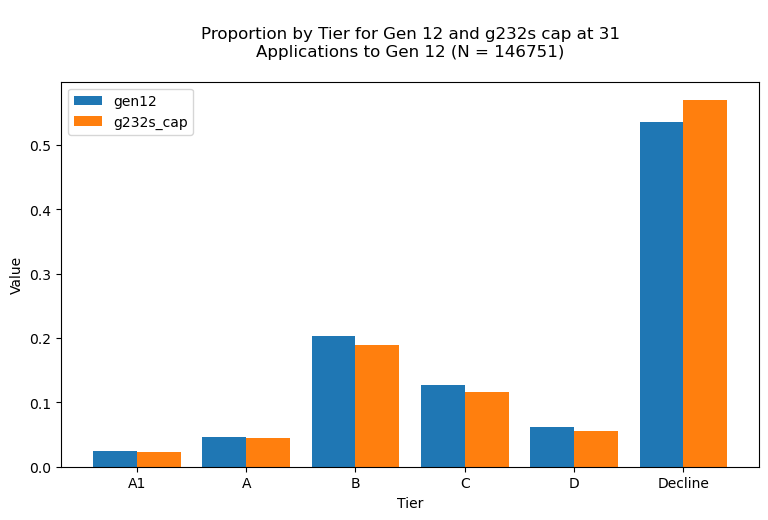

In [7]:
int_nrows = df.shape[0]
flt_width = 0.4
x = range(0, df_freq.shape[0])  # X locations for groups
# ax
str_title = f"""
Proportion by Tier for Gen 12 and g232s cap at 31
Applications to Gen 12 (N = {int_nrows})
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)

ax.bar([i - flt_width/2 for i in x], df_freq['proportion_gen12'], width=flt_width, label='gen12')
ax.bar([i + flt_width/2 for i in x], df_freq['proportion_g232s_cap'], width=flt_width, label='g232s_cap')

# Format plot
ax.set_xticks(x)
ax.set_xticklabels(df_freq['tier'])
ax.set_xlabel('Tier')
ax.set_ylabel('Value')
ax.legend()
plt.show()

#### Compare tiers rp01s

In [8]:
# gen 12
str_col = 'tier_gen12'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_gen12 = ser_freq.reset_index()
df_freq_gen12.columns = ['tier', 'proportion_gen12']

# gen 13
str_col = 'tier_rp01s'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_rp01s = ser_freq.reset_index()
df_freq_rp01s.columns = ['tier', 'proportion_rp01s_cap']

# join
df_freq = pd.merge(
    left=df_freq_gen12,
    right=df_freq_rp01s,
    on='tier',
    how='left',
)

# sort
df_freq['sort'] = df_freq['tier'].map(dict_sort)
df_freq.sort_values(by='sort', ascending=True, inplace=True)
df_freq.drop('sort', axis=1, inplace=True)

# show
df_freq

,tier,proportion_gen12,proportion_rp01s_cap
5,A1,0.024559,0.024341
4,A,0.046978,0.046323
1,B,0.203603,0.195787
2,C,0.126568,0.120687
3,D,0.061969,0.058902
0,Decline,0.536323,0.553959


#### Plot rp01s

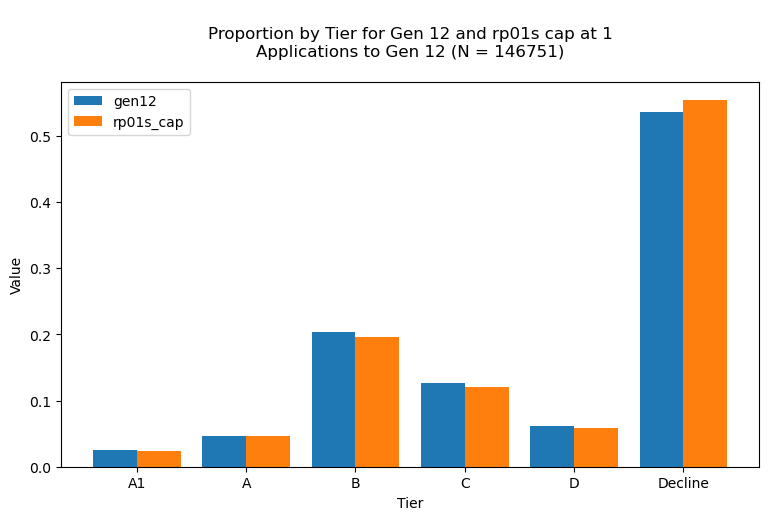

In [9]:
int_nrows = df.shape[0]
flt_width = 0.4
x = range(0, df_freq.shape[0])  # X locations for groups
# ax
str_title = f"""
Proportion by Tier for Gen 12 and rp01s cap at 1
Applications to Gen 12 (N = {int_nrows})
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)

ax.bar([i - flt_width/2 for i in x], df_freq['proportion_gen12'], width=flt_width, label='gen12')
ax.bar([i + flt_width/2 for i in x], df_freq['proportion_rp01s_cap'], width=flt_width, label='rp01s_cap')

# Format plot
ax.set_xticks(x)
ax.set_xticklabels(df_freq['tier'])
ax.set_xlabel('Tier')
ax.set_ylabel('Value')
ax.legend()
plt.show()

#### Compare LTV

In [10]:
# gen 12
str_col = 'tier_gen12'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_gen12 = ser_freq.reset_index()
df_freq_gen12.columns = ['tier', 'proportion_gen12']

# gen 13
str_col = 'tier_ltv'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_ltv = ser_freq.reset_index()
df_freq_ltv.columns = ['tier', 'proportion_ltv_cap']

# join
df_freq = pd.merge(
    left=df_freq_gen12,
    right=df_freq_ltv,
    on='tier',
    how='left',
)

# sort
df_freq['sort'] = df_freq['tier'].map(dict_sort)
df_freq.sort_values(by='sort', ascending=True, inplace=True)
df_freq.drop('sort', axis=1, inplace=True)

# show
df_freq

,tier,proportion_gen12,proportion_ltv_cap
5,A1,0.024559,0.041485
4,A,0.046978,0.044797
1,B,0.203603,0.196217
2,C,0.126568,0.122091
3,D,0.061969,0.060034
0,Decline,0.536323,0.535376


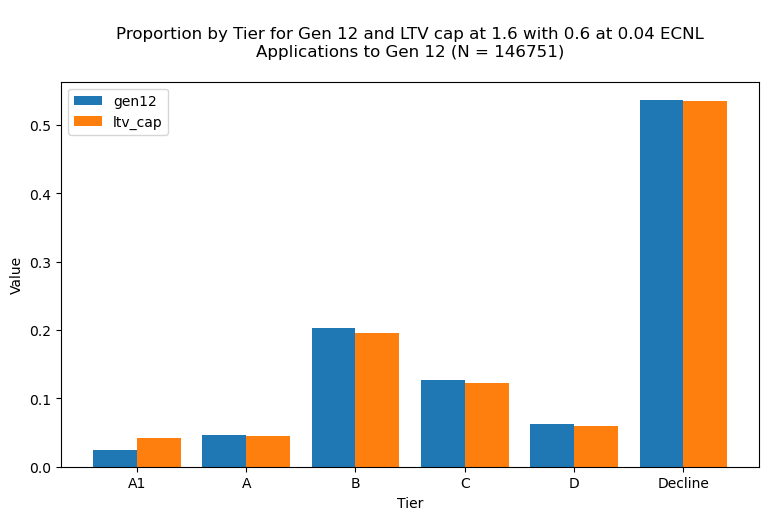

In [11]:
int_nrows = df.shape[0]
flt_width = 0.4
x = range(0, df_freq.shape[0])  # X locations for groups
# ax
str_title = f"""
Proportion by Tier for Gen 12 and LTV cap at 1.6 with 0.6 at 0.04 ECNL
Applications to Gen 12 (N = {int_nrows})
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)

ax.bar([i - flt_width/2 for i in x], df_freq['proportion_gen12'], width=flt_width, label='gen12')
ax.bar([i + flt_width/2 for i in x], df_freq['proportion_ltv_cap'], width=flt_width, label='ltv_cap')

# Format plot
ax.set_xticks(x)
ax.set_xticklabels(df_freq['tier'])
ax.set_xlabel('Tier')
ax.set_ylabel('Value')
ax.legend()
plt.show()

# ENG-wtd_avg

In [12]:
# pull data
df = pd.read_parquet(str_uri)

# subset BKs
df = df[df['intopenbktype__app'].isna()]

# impute
df['ENG-wtd_avg'] = df['flt_wtd_avg_open__tu_pmthx_raw'].fillna(df['flt_wtd_avg_closed__tu_pmthx_raw'])

# group by
df = df.groupby('accountid').agg({
#     'pd_gen13': 'mean', 
#     'lgd_gen13': 'mean',
    'pd_gen12': 'mean', 
    'lgd_gen12': 'mean',    
#     'g232s__tu': 'max',
#     'rp01s__tu': 'max',
    'ENG-wtd_avg': 'mean',
}).reset_index()

# calculate ecnl_gen12
df['ecnl_gen12'] = df['pd_gen12'] * df['lgd_gen12'] * flt_factor_24_to_72

# calculate updated ecnl
df['ecnl_wtd_avg'] = df.apply(lambda row: 1.0 if row['ENG-wtd_avg'] < 0.5 else row['ecnl_gen12'], axis=1)

# get tier
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

df['tier_wtd_avg'] = df['ecnl_wtd_avg'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

# show
df

df_tmp2 = df[['accountid', 'tier_wtd_avg']]

#### Compare wtd_avg

In [13]:
# gen 12
str_col = 'tier_gen12'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_gen12 = ser_freq.reset_index()
df_freq_gen12.columns = ['tier', 'proportion_gen12']

# gen 13
str_col = 'tier_wtd_avg'
ser_freq = df[str_col].value_counts(normalize=True)
df_freq_wtd_avg = ser_freq.reset_index()
df_freq_wtd_avg.columns = ['tier', 'proportion_wtd_avg_cap']

# join
df_freq = pd.merge(
    left=df_freq_gen12,
    right=df_freq_wtd_avg,
    on='tier',
    how='left',
)

# sort
df_freq['sort'] = df_freq['tier'].map(dict_sort)
df_freq.sort_values(by='sort', ascending=True, inplace=True)
df_freq.drop('sort', axis=1, inplace=True)

# show
df_freq

,tier,proportion_gen12,proportion_wtd_avg_cap
5,A1,0.019861,0.018258
4,A,0.039560,0.034884
1,B,0.193768,0.158152
2,C,0.127630,0.100078
3,D,0.062940,0.049146
0,Decline,0.556241,0.639481


#### plot

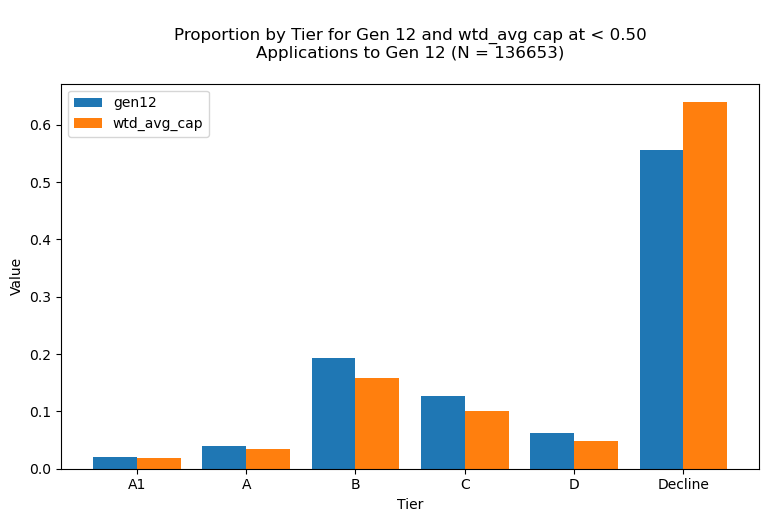

In [14]:
int_nrows = df.shape[0]
flt_width = 0.4
x = range(0, df_freq.shape[0])  # X locations for groups
# ax
str_title = f"""
Proportion by Tier for Gen 12 and wtd_avg cap at < 0.50
Applications to Gen 12 (N = {int_nrows})
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)

ax.bar([i - flt_width/2 for i in x], df_freq['proportion_gen12'], width=flt_width, label='gen12')
ax.bar([i + flt_width/2 for i in x], df_freq['proportion_wtd_avg_cap'], width=flt_width, label='wtd_avg_cap')

# Format plot
ax.set_xticks(x)
ax.set_xticklabels(df_freq['tier'])
ax.set_xlabel('Tier')
ax.set_ylabel('Value')
ax.legend()
plt.show()

# Combined effect on approvals

In [15]:
# join
df_combined = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='accountid',
    how='left',
)

# fill tier_wtd_avg with regular gen12 tier if it's NaN
df_combined['tier_wtd_avg'] = df_combined['tier_wtd_avg'].fillna(df_combined['tier_gen12'])

# get combined_effect_tier
df_combined['tier_combined_effect'] = df_combined.apply(lambda row: 
    'Decline' if 'Decline' in [row['tier_g232s'], row['tier_rp01s'], row['tier_ltv'], row['tier_wtd_avg']] 
    else row['tier_gen12'], axis=1)

df_combined

,accountid,tier_gen12,tier_g232s,tier_rp01s,tier_ltv,tier_wtd_avg,tier_combined_effect
0,5782431,Decline,Decline,Decline,Decline,Decline,Decline
1,7861802,Decline,Decline,Decline,Decline,Decline,Decline
2,7986128,C,C,C,C,C,C
3,8033187,A,A,A,A,A,A
4,8155274,B,B,B,B,B,B
...,...,...,...,...,...,...,...
146746,8680649,Decline,Decline,Decline,Decline,Decline,Decline
146747,8680650,Decline,Decline,Decline,Decline,Decline,Decline
146748,8680651,Decline,Decline,Decline,Decline,Decline,Decline
146749,8680653,Decline,Decline,Decline,Decline,Decline,Decline


In [16]:
# gen 12
str_col = 'tier_gen12'
ser_freq = df_combined[str_col].value_counts(normalize=True)
df_freq_gen12 = ser_freq.reset_index()
df_freq_gen12.columns = ['tier', 'proportion_gen12']

# gen 13
str_col = 'tier_wtd_avg'
ser_freq = df_combined[str_col].value_counts(normalize=True)
df_freq_combined = ser_freq.reset_index()
df_freq_combined.columns = ['tier', 'proportion_combined_effect']

# join
df_freq = pd.merge(
    left=df_freq_gen12,
    right=df_freq_combined,
    on='tier',
    how='left',
)

# sort
df_freq['sort'] = df_freq['tier'].map(dict_sort)
df_freq.sort_values(by='sort', ascending=True, inplace=True)
df_freq.drop('sort', axis=1, inplace=True)

# show
df_freq

,tier,proportion_gen12,proportion_combined_effect
5,A1,0.024559,0.023066
4,A,0.046978,0.042623
1,B,0.203603,0.170438
2,C,0.126568,0.100912
3,D,0.061969,0.049124
0,Decline,0.536323,0.613836


#### plot it

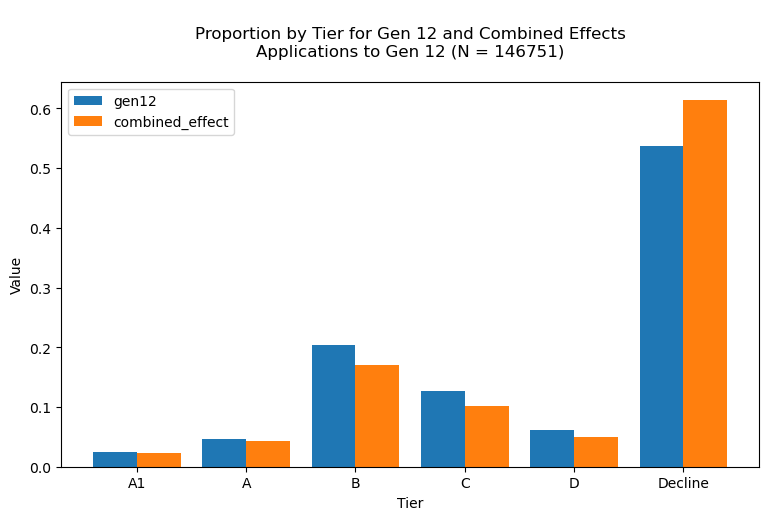

In [17]:
int_nrows = df_combined.shape[0]
flt_width = 0.4
x = range(0, df_freq.shape[0])  # X locations for groups
# ax
str_title = f"""
Proportion by Tier for Gen 12 and Combined Effects
Applications to Gen 12 (N = {int_nrows})
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)

ax.bar([i - flt_width/2 for i in x], df_freq['proportion_gen12'], width=flt_width, label='gen12')
ax.bar([i + flt_width/2 for i in x], df_freq['proportion_combined_effect'], width=flt_width, label='combined_effect')

# Format plot
ax.set_xticks(x)
ax.set_xticklabels(df_freq['tier'])
ax.set_xlabel('Tier')
ax.set_ylabel('Value')
ax.legend()
plt.show()